In [29]:
#10-11-25
#qr w/o RH
#Mass-weighted random sampling
#for ht in range(32, 91, 9).

import time
overall_start_time = time.time()
import os
import sys

import numpy as np
import pandas as pd
#%matplotlib inline  #won't work for .py
import matplotlib.pyplot as plt
import xarray as xr

# import json_file_editer as JFE
from File_management import json_file_editer as JFE
from Calculation import job_manager 
from Tools import dataset_init
from Log_management import Log

import xgboost as xgb
from xgboost import XGBClassifier
from xgboost import XGBRegressor
from xgboost import plot_importance

import seaborn as sns
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.metrics import r2_score

#random forest
import warnings
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import KNNImputer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import f1_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score

warnings.filterwarnings('ignore')

#ISLP
from matplotlib.pyplot import subplots
from statsmodels.datasets import get_rdataset
import sklearn.model_selection as skm
from ISLP import load_data, confusion_table
from ISLP.models import ModelSpec as MS

from sklearn.tree import (DecisionTreeClassifier as DTC,
 DecisionTreeRegressor as DTR,
 plot_tree,
 export_text)
from sklearn.metrics import (accuracy_score,
 log_loss)
from sklearn.ensemble import \
 (RandomForestRegressor as RF,
 GradientBoostingRegressor as GBR)
from ISLP.bart import BART

#################################################################
Log.init_log(os.path.join('./output'), filename=f"Log_ML.txt")
Log.add_to_log("Log nicely initialized ")

options_json=JFE.get_json_data("options.json")
options_json["Header"]["status"]
chunks = {}
myJob = job_manager.JobManager(options_json)
ds = dataset_init.ds_init_3d(myJob, chunks={}) 

The job folder path : ./output/Log_ML.txt
2025 Nov 11 17:05:36 > Log nicely initialized 
2025 Nov 11 17:05:36 > (DI0010) making data from P-O files requires small differences in the code, hardly automisable.
2025 Nov 11 17:05:36 > (DI0020) Starting PO dataset creation from /work/mh0066/m301130/projects/scheme_comparison/icon-mpim/build/experiments/pod0001
2025 Nov 11 17:05:36 > (DI0021) Found 8 time-varying files in date range
2025 Nov 11 17:05:36 > (DI0022) Loading vertical grid data from /work/mh0066/m301130/projects/scheme_comparison/icon-mpim/build/experiments/pod0001/pod0001_atm_vgrid_ml.nc
2025 Nov 11 17:05:36 > (DI0023) Grid variables available: ['clon_bnds', 'clat_bnds', 'height_bnds', 'height_2_bnds', 'zghalf', 'zg', 'dzghalf', 'clon', 'clat', 'height', 'height_2']
2025 Nov 11 17:05:36 > (DI0024) Dimensions in vgrid: FrozenMappingWarningOnValuesAccess({'ncells': 20971520, 'vertices': 3, 'height': 60, 'bnds': 2, 'height_2': 60})
2025 Nov 11 17:05:36 > (DI0037) Loading horizonta

In [30]:
seed = 1
sample_frac = 0.001 

ht=31
data=ds.sel(height=ht, height_2=ht) 

total = data['clw'] + data['cli']
data['clw/(clw+cli)'] = data['clw'].where(total != 0, 0) / total.where(total != 0, 1)
data['cli/(clw+cli)'] = data['cli'].where(total != 0, 0) / total.where(total != 0, 1)

total_precipitates = data['qr'] + data['qs']+ data['qg']
data['qr/(qr+qs+qg)'] = data['qr'].where(total_precipitates != 0, 0) / total_precipitates.where(total_precipitates != 0, 1)
data['qs/(qr+qs+qg)'] = data['qs'].where(total_precipitates != 0, 0) / total_precipitates.where(total_precipitates != 0, 1)
data['qg/(qr+qs+qg)'] = data['qg'].where(total_precipitates != 0, 0) / total_precipitates.where(total_precipitates != 0, 1)


In [31]:
df = data.to_dataframe() #.sample(frac=1, random_state=seed) #frac=sample_frac

In [32]:

# df = data.to_dataframe().sample(frac=sample_frac, random_state=seed)

dfs = [df]  
for ht in range(32, 91, 19): #(32, 91, 9)
    data = ds.sel(height=ht, height_2=ht)

    total = data['clw'] + data['cli']
    data['clw/(clw+cli)'] = data['clw'].where(total != 0, 0) / total.where(total != 0, 1)
    data['cli/(clw+cli)'] = data['cli'].where(total != 0, 0) / total.where(total != 0, 1)

    total_precipitates = data['qr'] + data['qs']+ data['qg']
    data['qr/(qr+qs+qg)'] = data['qr'].where(total_precipitates != 0, 0) / total_precipitates.where(total_precipitates != 0, 1)
    data['qs/(qr+qs+qg)'] = data['qs'].where(total_precipitates != 0, 0) / total_precipitates.where(total_precipitates != 0, 1)
    data['qg/(qr+qs+qg)'] = data['qg'].where(total_precipitates != 0, 0) / total_precipitates.where(total_precipitates != 0, 1)

    df_sampled=data.to_dataframe() #.sample(frac=1, random_state= seed+ht) #frac=sample_frac
    dfs.append(df_sampled) 
    print(f"Last value of clon in df with height {ht} is", df_sampled['clon'].iloc[-1])

df = pd.concat(dfs, ignore_index=True)

# print('length of dfs: ',len(dfs))
# print('len of dfs[0]: ', len(dfs[0]))
prod= len(dfs[0]) * len(dfs)
print("Expected length of df: ", prod)
print('Final length of df: ', len(df))

Last value of clon in df with height 32 is 1.3343108942333097
Last value of clon in df with height 51 is 1.3343108942333097
Last value of clon in df with height 70 is 1.3343108942333097
Last value of clon in df with height 89 is 1.3343108942333097
Expected length of df:  104857600
Final length of df:  104857600


In [33]:
threshold = 5e-12
df_new = df[(df['cli'] + df['clw'] + df['qr'] + df['qg'] + df['qs']) >= threshold]
# print('df- After threshold-1:')
# print(df_new)
if df_new.empty:
    df_new = df

df = df_new
# print('df after threshold-2:\n', df)

In [10]:
# #RH from SH
# def RH_from_SH(pfull, hus, ta, T_0= 273.16):
#     RH = 0.26 * pfull * hus / np.exp(17.67 * (ta - T_0) / (ta - 29.65))
#     return RH

In [11]:
# df['RH']=RH_from_SH(df['pfull'], df['hus'], df['ta'])

In [12]:
# count=0
# for i in df['RH']:
#     if i>100 or i<0:
#         count+=1
# print("incorrect count = ", count)
# print("incorrect count percent = ", 100*count/len(df['RH']))

In [13]:
# df['RH']= df['RH'].clip(lower=0, upper=100)

In [34]:
# col=df.pop('RH')
# df.insert(16, 'RH', col) #hus is at 15th position
df.pop('hus')

df['clw+cli']=df['clw']+df['cli']

col=df.pop('clw+cli')
df.insert(24, 'clw+cli', col) 

df.columns

Index(['clon', 'clat', 'cell_area', 'pr', 'tas', 'clivi', 'cllvi', 'qgvi',
       'qrvi', 'qsvi', 'clw', 'cli', 'qr', 'qg', 'qs', 'ta', 'wa', 'rho',
       'dzghalf', 'ua', 'va', 'pfull', 'height', 'height_2', 'clw+cli',
       'clw/(clw+cli)', 'cli/(clw+cli)', 'qr/(qr+qs+qg)', 'qs/(qr+qs+qg)',
       'qg/(qr+qs+qg)'],
      dtype='object')

In [35]:
#Include 'cloud liquid water path + cloud ice path' as a feature.

df['cllvi+clivi']=df['cllvi']+df['clivi']

col=df.pop('cllvi+clivi')
df.insert(25, 'cllvi+clivi', col) 

# df.to_csv("df.csv", index=False)
df.columns

Index(['clon', 'clat', 'cell_area', 'pr', 'tas', 'clivi', 'cllvi', 'qgvi',
       'qrvi', 'qsvi', 'clw', 'cli', 'qr', 'qg', 'qs', 'ta', 'wa', 'rho',
       'dzghalf', 'ua', 'va', 'pfull', 'height', 'height_2', 'clw+cli',
       'cllvi+clivi', 'clw/(clw+cli)', 'cli/(clw+cli)', 'qr/(qr+qs+qg)',
       'qs/(qr+qs+qg)', 'qg/(qr+qs+qg)'],
      dtype='object')

In [36]:
# m_ci_j=dzghalf*rho*cell_area*(clw+cli)
df['m_ci']=df['dzghalf']*df['rho']*df['cell_area']* (df['clw']+df['cli'])

col=df.pop('m_ci')
df.insert(26, 'm_ci', col) 

df.columns

Index(['clon', 'clat', 'cell_area', 'pr', 'tas', 'clivi', 'cllvi', 'qgvi',
       'qrvi', 'qsvi', 'clw', 'cli', 'qr', 'qg', 'qs', 'ta', 'wa', 'rho',
       'dzghalf', 'ua', 'va', 'pfull', 'height', 'height_2', 'clw+cli',
       'cllvi+clivi', 'm_ci', 'clw/(clw+cli)', 'cli/(clw+cli)',
       'qr/(qr+qs+qg)', 'qs/(qr+qs+qg)', 'qg/(qr+qs+qg)'],
      dtype='object')

In [37]:
df = df.sort_values(by='m_ci', ascending=False)
df

,clon,clat,cell_area,pr,tas,clivi,cllvi,qgvi,qrvi,qsvi,...,height,height_2,clw+cli,cllvi+clivi,m_ci,clw/(clw+cli),cli/(clw+cli),qr/(qr+qs+qg),qs/(qr+qs+qg),qg/(qr+qs+qg)
68160803,1.264630,0.200923,2.519046e+07,2.310373e-02,NaN,4.870968e-02,12.394000,1.291498e-02,3.781074e+00,4.946395e-02,...,70.0,70.0,0.006621,1.244271e+01,4.585490e+07,1.0,3.095263e-10,9.999575e-01,1.026921e-08,4.247174e-05
77412108,2.854642,-0.213120,2.456310e+07,1.436195e-02,NaN,1.045773e-01,11.816016,1.081200e+00,2.073902e+00,4.016474e-02,...,70.0,70.0,0.006472,1.192059e+01,4.309189e+07,1.0,1.235514e-13,9.739528e-01,6.137612e-11,2.604726e-02
72193171,2.103945,0.044482,2.455383e+07,4.751395e-03,NaN,3.114857e-03,8.859386,8.728714e-06,1.045036e+00,2.212848e-03,...,70.0,70.0,0.006286,8.862501e+00,4.213562e+07,1.0,3.282495e-14,1.000000e+00,1.733082e-11,2.479498e-13
77634220,2.607319,-0.139179,2.521002e+07,1.877668e-02,NaN,1.104497e-03,9.583341,4.203978e-05,4.414821e+00,6.296596e-04,...,70.0,70.0,0.005945,9.584445e+00,4.096602e+07,1.0,1.298861e-12,9.999974e-01,3.797925e-09,2.532315e-06
77412110,2.854072,-0.212816,2.457134e+07,7.138449e-03,NaN,1.734066e-01,10.285022,1.035762e+00,8.622455e-01,5.651506e-02,...,70.0,70.0,0.005963,1.045843e+01,3.968965e+07,1.0,1.300443e-13,9.889801e-01,4.850900e-11,1.101996e-02
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
85067827,2.205010,0.994329,2.497671e+07,3.044711e-09,NaN,1.855781e-09,0.000000,1.210060e-12,2.658350e-13,2.052282e-07,...,89.0,89.0,0.000000,1.855781e-09,0.000000e+00,0.0,0.000000e+00,4.550085e-07,9.999996e-01,8.281159e-11
65689104,-3.036802,0.631134,2.326579e+07,3.206788e-16,NaN,3.277015e-12,0.000000,4.630145e-07,3.477398e-13,5.589520e-05,...,70.0,70.0,0.000000,3.277015e-12,0.000000e+00,0.0,0.000000e+00,4.385579e-09,9.624234e-01,3.757657e-02
64933669,3.104014,0.644444,2.325905e+07,5.003904e-17,NaN,4.867923e-11,0.000000,5.212730e-06,2.273158e-13,1.205933e-04,...,70.0,70.0,0.000000,4.867923e-11,0.000000e+00,0.0,0.000000e+00,2.901436e-10,9.028304e-01,9.716959e-02
67253689,-0.233116,0.975962,2.504377e+07,5.432710e-14,NaN,2.413723e-05,0.068293,2.660295e-04,8.937045e-10,6.558382e-05,...,70.0,70.0,0.000000,6.831761e-02,0.000000e+00,0.0,0.000000e+00,3.773288e-10,1.000000e+00,3.260221e-10


In [38]:
df = df.reset_index(drop=True)
df['m_ci']

0           4.585490e+07
1           4.309189e+07
2           4.213562e+07
3           4.096602e+07
4           3.968965e+07
                ...     
18601726    0.000000e+00
18601727    0.000000e+00
18601728    0.000000e+00
18601729    0.000000e+00
18601730    0.000000e+00
Name: m_ci, Length: 18601731, dtype: float64

In [39]:
total_mass = df['m_ci'].sum()
total_mass #kg

np.float64(2140227072689.8574)

In [40]:
df['cum_mass'] = df['m_ci'].cumsum()

col=df.pop('cum_mass')
df.insert(27, 'cum_mass', col) 

df.columns

Index(['clon', 'clat', 'cell_area', 'pr', 'tas', 'clivi', 'cllvi', 'qgvi',
       'qrvi', 'qsvi', 'clw', 'cli', 'qr', 'qg', 'qs', 'ta', 'wa', 'rho',
       'dzghalf', 'ua', 'va', 'pfull', 'height', 'height_2', 'clw+cli',
       'cllvi+clivi', 'm_ci', 'cum_mass', 'clw/(clw+cli)', 'cli/(clw+cli)',
       'qr/(qr+qs+qg)', 'qs/(qr+qs+qg)', 'qg/(qr+qs+qg)'],
      dtype='object')

In [41]:
#Adding another column; qr+qg+qs and use it later as an input feature

df['qr+qg+qs'] = df['qr'] + df['qg'] + df['qs']

col=df.pop('qr+qg+qs')
df.insert(28, 'qr+qg+qs', col)

df.columns


Index(['clon', 'clat', 'cell_area', 'pr', 'tas', 'clivi', 'cllvi', 'qgvi',
       'qrvi', 'qsvi', 'clw', 'cli', 'qr', 'qg', 'qs', 'ta', 'wa', 'rho',
       'dzghalf', 'ua', 'va', 'pfull', 'height', 'height_2', 'clw+cli',
       'cllvi+clivi', 'm_ci', 'cum_mass', 'qr+qg+qs', 'clw/(clw+cli)',
       'cli/(clw+cli)', 'qr/(qr+qs+qg)', 'qs/(qr+qs+qg)', 'qg/(qr+qs+qg)'],
      dtype='object')

In [42]:
n_samples= int(np.floor(len(df) * 0.1))

np.random.seed(29)

random_values = np.random.uniform(0, total_mass, size=n_samples)

print('Random values: ', random_values)

indices= np.searchsorted(df['cum_mass'].values, random_values)

df_orig=df

df = df.iloc[indices].reset_index(drop=True)

Random values:  [1.84864251e+12 6.09763460e+11 1.56785305e+11 ... 1.96622867e+12
 4.53160935e+10 1.30384144e+12]


In [43]:
df.columns

Index(['clon', 'clat', 'cell_area', 'pr', 'tas', 'clivi', 'cllvi', 'qgvi',
       'qrvi', 'qsvi', 'clw', 'cli', 'qr', 'qg', 'qs', 'ta', 'wa', 'rho',
       'dzghalf', 'ua', 'va', 'pfull', 'height', 'height_2', 'clw+cli',
       'cllvi+clivi', 'm_ci', 'cum_mass', 'qr+qg+qs', 'clw/(clw+cli)',
       'cli/(clw+cli)', 'qr/(qr+qs+qg)', 'qs/(qr+qs+qg)', 'qg/(qr+qs+qg)'],
      dtype='object')

In [ ]:
#overall MLR code
X = df.iloc[:, [0,1,15,16,17,19,20,21,22,24,25,28]].values 
y = df.iloc[:, [-3]].values 

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=5)
cols= [0,1,15,16,17,19,20,21,22,24,25,28]
feature_names=df.columns[cols].tolist()

from sklearn import linear_model

regr=linear_model.LinearRegression()
regr.fit(X_train,y_train)

y_predicted = regr.predict(X_test)
y_predicted = np.clip(y_predicted, 0, 1)

#Error Analysis on TEST data
#MSE_test
mse_TEST= np.mean((y_test- y_predicted)**2)
print(f'MSE_TEST: {mse_TEST}')

#rmse_test
rmse_TEST = np.sqrt(np.mean((y_test - y_predicted)**2))
print(f'RMSE_TEST: {rmse_TEST}')
# print(f'MSE_TEST: {(rmse_TEST)**2}')

#mae_TEST
mae_TEST = np.mean(abs(y_test - y_predicted))
print(f'mae_TEST: {mae_TEST}')

#R2_test_sklearn
r2_sklearn = r2_score(y_test, y_predicted)
print("R² score:", r2_sklearn)

#Coefficient
coef_list= regr.coef_[0]

coef_table = pd.DataFrame(
{
    'Feature': feature_names,
    'Coefficient': coef_list
}
)

#Sort by absolute coeff val

coef_table['abs(Coefficient)'] = coef_table['Coefficient'].abs()
coef_table.sort_values(by='abs(Coefficient)', ascending=False, inplace=True)
print(coef_table)


MSE_TEST: 0.055382879071632064
RMSE_TEST: 0.2353356731811649
mae_TEST: 0.1628911903029709
R² score: 0.6915761981082242
        Feature  Coefficient  abs(Coefficient)
9       clw+cli   145.295530        145.295530
11     qr+qg+qs   -10.375225         10.375225
4           rho    -6.967567          6.967567
8        height    -0.031807          0.031807
1          clat     0.021334          0.021334
3            wa    -0.011387          0.011387
10  cllvi+clivi    -0.005329          0.005329
0          clon    -0.004487          0.004487
5            ua     0.003137          0.003137
2            ta    -0.001183          0.001183
6            va    -0.000418          0.000418
7         pfull     0.000106          0.000106


In [ ]:
pairs = [(name, abs(coef)) for name, coef in zip(feature_names, coef_list)]
pairs.sort(key=lambda x: x[1], reverse=True)

for name, coef in pairs:
    print(f"{name}:{coef:.6f}")


clw+cli:145.295530
qr+qg+qs:10.375225
rho:6.967567
height:0.031807
clat:0.021334
wa:0.011387
cllvi+clivi:0.005329
clon:0.004487
ua:0.003137
ta:0.001183
va:0.000418
pfull:0.000106


In [ ]:
# import seaborn as sns

# plt.figure(figsize=(8,6))
# sns.scatterplot(x=y_test.flatten(), y=y_predicted.flatten(), alpha=0.7)
# plt.xlabel("Actual Values")
# plt.ylabel("Predicted Values")
# plt.title("Actual vs Predicted Values (MLR)")
# # Add a perfect prediction line
# plt.plot([y_test.min(), y_test.max()],
#          [y_test.min(), y_test.max()],
#          color='red', lw=2)
# plt.show()


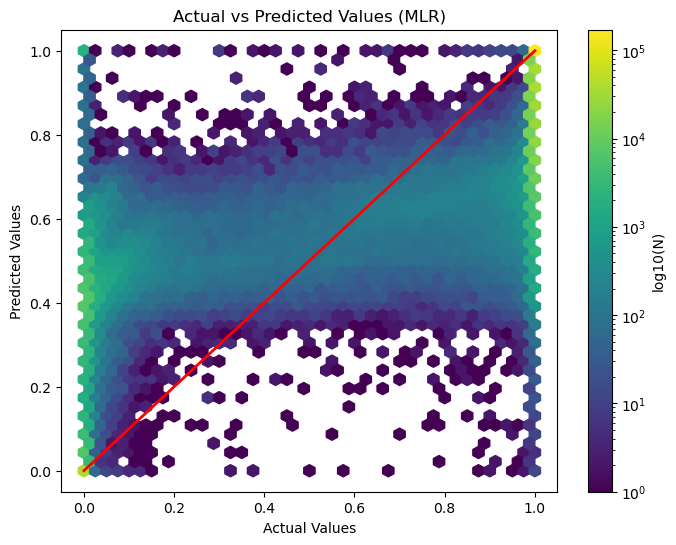

In [ ]:
plt.figure(figsize=(8,6))
plt.hexbin(
    y_test.flatten(), 
    y_predicted.flatten(), 
    gridsize=40,  # smaller → finer grid
    cmap='viridis', 
    bins='log'  # logarithmic scaling helps emphasize dense areas
)
plt.colorbar(label='log10(N)')
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color='red', lw=2
)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted Values (MLR)")
plt.show()


In [ ]:
##ft 16 ('RH') and -5 ('clw/(clw+cli)')
# df['RH']


In [ ]:
df['clw/(clw+cli)']

0          1.0
1          1.0
2          1.0
3          1.0
4          1.0
          ... 
3650874    1.0
3650875    1.0
3650876    1.0
3650877    1.0
3650878    0.0
Name: clw/(clw+cli), Length: 3650879, dtype: float32

In [ ]:
# plt.plot(df['RH'], df['clw/(clw+cli)'])

In [ ]:
# plt.scatter(df['RH'][::100], df['clw/(clw+cli)'][::100], s=2)
# plt.xlabel("RH")
# plt.ylabel("clw / (clw + cli)")
# plt.title("Scatter Plot: RH vs clw/(clw+cli)")
# plt.show()

In [ ]:
# plt.scatter(df['RH'][::100], df['clw/(clw+cli)'][::100], s=2)
# plt.xlim(95,100)
# plt.xlabel("RH")
# plt.ylabel("clw / (clw + cli)")
# plt.title("Scatter Plot: RH vs clw/(clw+cli)")
# plt.show()

In [ ]:
# plt.hexbin(
#     df['RH'][::100],
#     df['clw/(clw+cli)'][::100],
#     gridsize=60,    # adjust resolution (smaller = finer)
#     cmap='viridis', # color map
#     bins='log'      # use log scale for density
# )
# plt.colorbar(label='log10(N points)')
# # plt.xlim(95, 100)
# plt.xlabel("RH")
# plt.ylabel("clw / (clw + cli)")
# plt.title("Hexbin Density Plot: RH vs clw/(clw+cli)")
# plt.show()


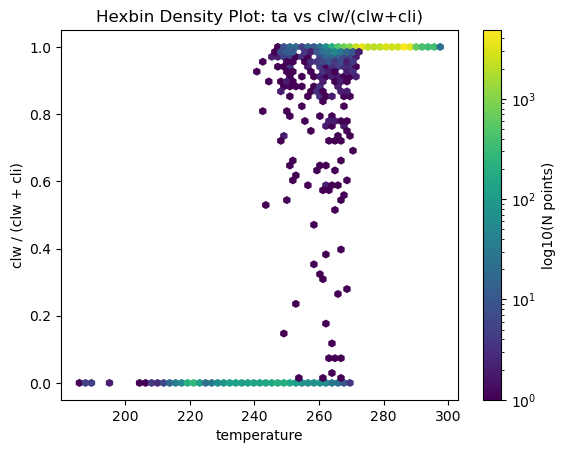

In [ ]:
#clw frac v/s ta
plt.hexbin(
    df['ta'][::100],
    df['clw/(clw+cli)'][::100],
    gridsize=60,    # adjust resolution (smaller = finer)
    cmap='viridis', # color map
    bins='log'      # use log scale for density
)
plt.colorbar(label='log10(N points)')
# plt.xlim(95, 100)
plt.xlabel("temperature")
plt.ylabel("clw / (clw + cli)")
plt.title("Hexbin Density Plot: ta vs clw/(clw+cli)")
plt.show()


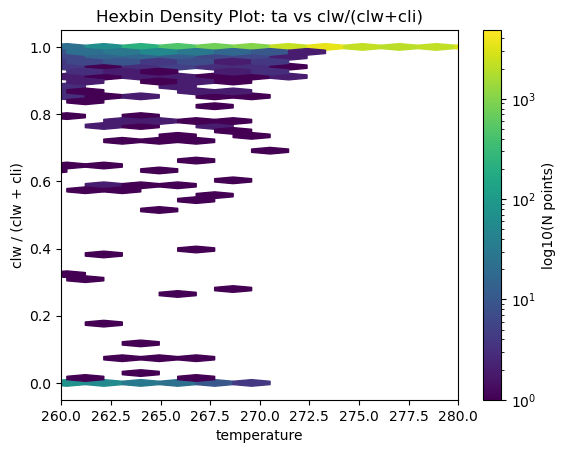

In [ ]:
#clw frac v/s ta
plt.hexbin(
    df['ta'][::100],
    df['clw/(clw+cli)'][::100],
    gridsize=60,    # adjust resolution (smaller = finer)
    cmap='viridis', # color map
    bins='log'      # use log scale for density
)
plt.colorbar(label='log10(N points)')
plt.xlim(260, 280)
plt.xlabel("temperature")
plt.ylabel("clw / (clw + cli)")
plt.title("Hexbin Density Plot: ta vs clw/(clw+cli)")
plt.show()


In [44]:
# print("Description of the df:\n")
# print(df[['cli', 'clw', 'qr', 'qg', 'qs']].describe())
# print(df[['cli', 'clw', 'qr', 'qg', 'qs']].isna().sum())
# print("Description ends\n")

# split data into X and y
# X = df.iloc[:, [15,16]].values # RH, ta
X = df.iloc[:, [0,1,15,16,17,19,20,21,24,25,28]].values 

y = df.iloc[:, [-3]].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=5)

cols= [0,1,15,16,17,19,20,21,24,25,28]
feature_names=df.columns[cols].tolist()
print(feature_names)

['clon', 'clat', 'ta', 'wa', 'rho', 'ua', 'va', 'pfull', 'clw+cli', 'cllvi+clivi', 'qr+qg+qs']


In [ ]:
#This is df and not X_train
# print('RH min: ', df['RH'].min())
# print('RH max: ', df['RH'].max())
# print('\n')
print('ta min: ', df['ta'].min())
print('ta max: ', df['ta'].max())
print('\n')
print('pfull min: ', df['pfull'].min())
print('pfull max: ', df['pfull'].max())
print('\n')
print('wa min: ', df['wa'].min())
print('wa max: ', df['wa'].max())
print('\n')

ta min:  185.23854
ta max:  298.29633


pfull min:  10953.423
pfull max:  99296.39


wa min:  -5.311124
wa max:  27.01307




In [ ]:
print(len(y_train))
print(len(y_test))

2920703
730176


Decision Tree

In [ ]:
# #Medium
# #Use Cross-Validation
# #best depth acc. to val data

# train_r2_scores=[]
# val_r2_scores=[]
# depths=range(1,11) #This seemed a reasonable depth range which is obtained from trial and error and articles online
# for depth in depths:
#     tree=DTR(max_depth=depth, random_state=1)
#     #train
#     tree.fit(X_train,y_train)
#     train_score=tree.score(X_train, y_train)
#     train_r2_scores.append(train_score)
#     # print(f"Depth {depth}: Training R2 score = {train_score} ") 

#     #val
    
#     val_scores= cross_val_score(tree, X_train, y_train, cv=5, scoring='r2')
#     # print(f"Depth {depth}: Mean Validation R2 score = {val_scores.mean()} ") #val_scores.mean(): .4f
#     val_r2_scores.append(val_scores.mean())

# #print(type(val_scores)) #<class 'numpy.ndarray'>
# #print(val_scores)
# max_val_r2_score=max(val_r2_scores)
# bestDepth=depths[val_r2_scores.index(max_val_r2_score)]
# print(f"\nMax. Validation R2 score: {max_val_r2_score} is at depth (bestDepth): {bestDepth}") #Validation R2 score is different from Test R2 score

# #Plotting
# plt.figure() #figsize=(8,5)
# plt.plot(depths, train_r2_scores, marker='o', label='Training R2')
# plt.plot(depths, val_r2_scores, marker='s', label='Validation R2')
# plt.xlabel("Tree Depth")
# plt.ylabel("R2 score")
# plt.title("Decision Tree Performance vs Depth")
# plt.legend()
# plt.grid(True)
# plt.show()

In [ ]:
# #to find the best Depth and the best number of min samples in leaf
# depths = range(1, 21) #range(1, 21)
# min_samples_in_leaf = range(1, 41) #range(1,51)

# train_r2_scores = []
# val_r2_scores = []
# param_combinations = []

# best_val_score = -np.inf
# best_depth = None
# best_min_samples_leaf = None

# for depth in depths:
#     for min_samples in min_samples_in_leaf:
#         tree = DTR(max_depth=depth, min_samples_leaf=min_samples, random_state=1)

#         tree.fit(X_train, y_train)
#         train_score = tree.score(X_train, y_train)
      
#         val_scores = cross_val_score(tree, X_train, y_train, cv=5, scoring='r2')
#         val_mean = val_scores.mean()
       
#         train_r2_scores.append(train_score)
#         val_r2_scores.append(val_mean)
#         param_combinations.append((depth, min_samples))

#         if val_mean > best_val_score:
#             best_val_score = val_mean
#             best_depth = depth
#             best_min_samples_leaf = min_samples

# print(f"\nBest Validation R2 Score: {best_val_score: }")
# print(f"Best Parameters: max_depth={best_depth}, min_samples_leaf={best_min_samples_leaf}")

# #took 48 mins to run
# #eg: max_depth=14, min_samples_leaf=40

In [ ]:
# param_combinations = np.array(param_combinations)
# depths_arr = param_combinations[:, 0]
# min_samples_arr = param_combinations[:, 1]
# val_r2_scores = np.array(val_r2_scores)


# plt.figure(figsize=(10, 6))
# plt.tricontourf(depths_arr, min_samples_arr, val_r2_scores, levels=20, cmap='viridis')
# plt.colorbar(label="Mean CV (Validation) R2 Score")
# plt.xlabel("Tree Depth")
# plt.ylabel("Min Samples in Leaf")
# plt.title("Decision Tree Cross-Validation Performance Grid Search")
# plt.show()


[Text(0.5209263392857143, 0.9375, 'ta <= 273.144\nsquared_error = 0.182\nsamples = 1488138\nvalue = 0.69'),
 Text(0.26060267857142855, 0.8125, 'ta <= 271.221\nsquared_error = 0.05\nsamples = 428118\nvalue = 0.075'),
 Text(0.3907645089285714, 0.875, 'True  '),
 Text(0.12834821428571427, 0.6875, 'clw+cli <= 0.001\nsquared_error = 0.01\nsamples = 345054\nvalue = 0.02'),
 Text(0.07142857142857142, 0.5625, 'qr+qg+qs <= 0.0\nsquared_error = 0.006\nsamples = 332820\nvalue = 0.014'),
 Text(0.03571428571428571, 0.4375, 'ta <= 266.876\nsquared_error = 0.097\nsamples = 5255\nvalue = 0.2'),
 Text(0.017857142857142856, 0.3125, 'clw+cli <= 0.0\nsquared_error = 0.017\nsamples = 2651\nvalue = 0.059'),
 Text(0.008928571428571428, 0.1875, 'clw+cli <= 0.0\nsquared_error = 0.0\nsamples = 1678\nvalue = 0.001'),
 Text(0.004464285714285714, 0.0625, 'squared_error = 0.0\nsamples = 1599\nvalue = 0.0'),
 Text(0.013392857142857142, 0.0625, 'squared_error = 0.004\nsamples = 79\nvalue = 0.028'),
 Text(0.0267857142

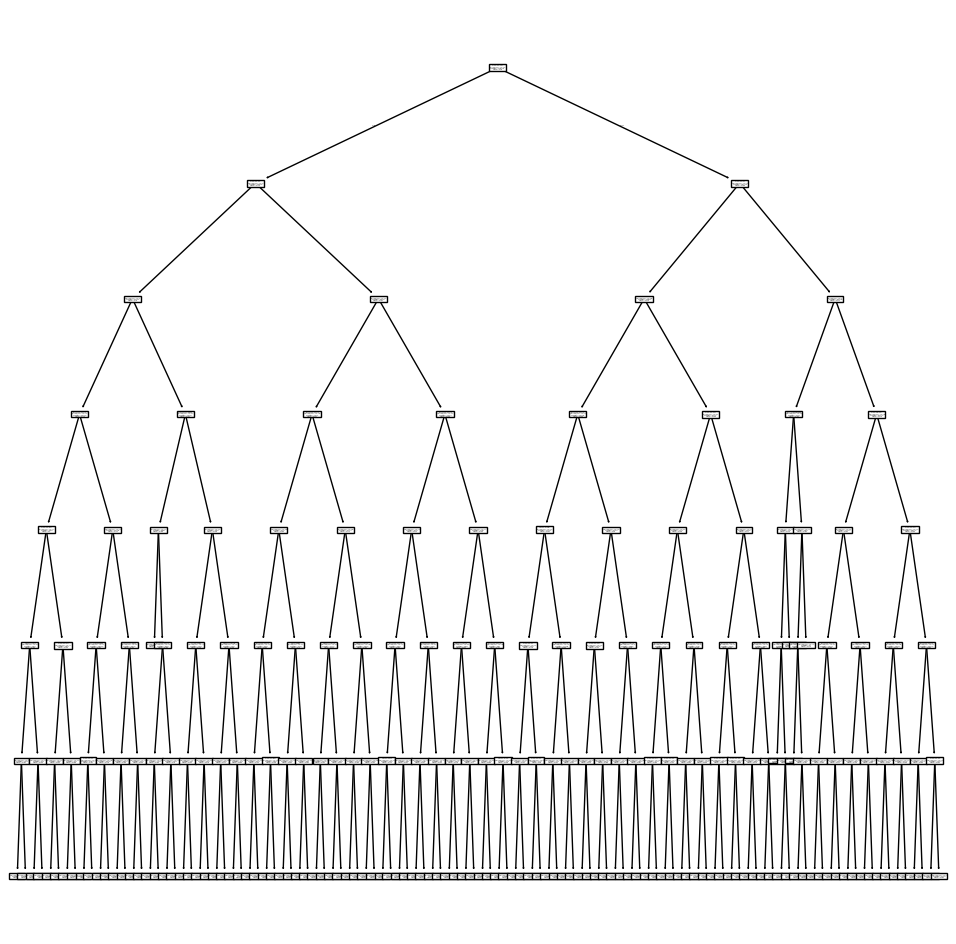

In [45]:
#Pathway-1
best_depth= 7 #14
best_min_samples_leaf=30 #40

reg=DTR(max_depth=best_depth, min_samples_leaf=best_min_samples_leaf, random_state=0)
reg.fit(X_train, y_train)
ax=subplots(figsize=(12,12))[1]
plot_tree(reg, feature_names=feature_names, ax=ax)

In [46]:
#Prediction
prediction_start_time = time.time()
y_pred = reg.predict(X_test)
prediction_end_time = time.time()
prediction_elapsed_time = prediction_end_time - prediction_start_time
print(f"Prediction- Elapsed time: {prediction_elapsed_time/60:.4f} minutes")

Prediction- Elapsed time: 0.0004 minutes


In [ ]:
y_pred

array([0.9996183 , 0.9996183 , 0.9996183 , ..., 0.9996183 , 0.06520557,
       0.9996183 ], shape=(730176,))

In [ ]:
y_test

array([[1.       ],
       [1.       ],
       [1.       ],
       ...,
       [1.       ],
       [0.0016352],
       [1.       ]], shape=(730176, 1), dtype=float32)

In [ ]:
type(y_test)

numpy.ndarray

In [47]:
y_test=y_test.ravel()
y_pred=y_pred.ravel()

In [48]:
#Error Analysis on TEST data
#MSE_test
mse_TEST= np.mean((y_test- y_pred)**2)
print(f'MSE_TEST: {mse_TEST}')

#rmse_test
rmse_TEST = np.sqrt(np.mean((y_test - y_pred)**2))
print(f'RMSE_TEST: {rmse_TEST}')
# print(f'MSE_TEST: {(rmse_TEST)**2}')

#mae_TEST
mae_TEST = np.mean(abs(y_test - y_pred))
print(f'mae_TEST: {mae_TEST}')

#R2_test_sklearn
r2_sklearn = r2_score(y_test, y_pred)
print("R² score before CCP:", r2_sklearn)

MSE_TEST: 0.010018112658339868
RMSE_TEST: 0.10009052232024702
mae_TEST: 0.041144117869665944
R² score before CCP: 0.9450720218218749


In [ ]:
# #Check on Sample data

# y_okati=np.array([[1,2],[3,4]])
# y_rendu=np.array([[1.5,3],[4,5]])

# # mse_TEST= np.mean((y_okati- y_rendu)**2)
# # print(f'MSE_TEST: {mse_TEST}')

# r2 = r2_score(y_okati, y_rendu)
# print("R2 score: ", r2)


In [ ]:
#Pathway-1
#This seems more robust because it uses CV and not test data to determine the best ccp_alpha

# ccp_path = reg.cost_complexity_pruning_path(X_train, y_train)

# kfold = skm.KFold(5,
# shuffle=True,
# random_state=10)

# grid = skm.GridSearchCV(reg,
# {'ccp_alpha': ccp_path.ccp_alphas},
# refit=True,
# cv=kfold,
# scoring='r2',
# n_jobs=-1)

# G = grid.fit(X_train, y_train)

# best_ = grid.best_estimator_
# print(best_)

# depth = best_.get_depth()
# print(depth)

In [ ]:
#Pathway-1
#Plot the best tree
# ax= subplots(figsize=(12,12))[1]
# plot_tree(G.best_estimator_, feature_names=feature_names, ax=ax) #after ccp

In [ ]:
# # ##Prediction
# prediction_start_time = time.time()
# y_pred = best_.predict(X_test)
# prediction_end_time = time.time()
# prediction_elapsed_time = prediction_end_time - prediction_start_time
# print(f"Prediction- Elapsed time: {prediction_elapsed_time/60:.4f} minutes")

# #########################################
# print('size of y_pred: ', len(y_pred))

In [49]:
##Prediction
prediction_start_time = time.time()
y_pred = reg.predict(X_test)
prediction_end_time = time.time()
prediction_elapsed_time = prediction_end_time - prediction_start_time
print(f"Prediction- Elapsed time: {prediction_elapsed_time/60:.4f} minutes")

#########################################
print('size of y_pred: ', len(y_pred))

Prediction- Elapsed time: 0.0004 minutes
size of y_pred:  372035


In [ ]:
y_test  

array([1.       , 1.       , 1.       , ..., 1.       , 0.0016352,
       1.       ], shape=(730176,), dtype=float32)

In [ ]:
y_pred

array([0.9996183 , 0.9996183 , 0.9996183 , ..., 0.9996183 , 0.06520557,
       0.9996183 ], shape=(730176,))

In [50]:
#Error Analysis on TEST data
#MSE_test
mse_TEST= np.mean((y_test- y_pred)**2)
print(f'MSE_TEST: {mse_TEST}')

#rmse_test
rmse_TEST = np.sqrt(np.mean((y_test - y_pred)**2))
print(f'RMSE_TEST: {rmse_TEST}')
# print(f'MSE_TEST: {(rmse_TEST)**2}')

#mae_TEST
mae_TEST = np.mean(abs(y_test - y_pred))
print(f'mae_TEST: {mae_TEST}')

#R2_test_sklearn
r2_sklearn = r2_score(y_test, y_pred)
print("R² score:", r2_sklearn)

MSE_TEST: 0.010018112658339868
RMSE_TEST: 0.10009052232024702
mae_TEST: 0.041144117869665944
R² score: 0.9450720218218749


In [51]:
# #DT-feature importances in descending order
# importance = best_.feature_importances_
# feature_scores= list(zip(feature_names, importance))
# feature_scores.sort(key=lambda x: x[1], reverse= True)
# for name, score in feature_scores:
#     print(f'{name}:{score:.6f}')

#DT-feature importances in descending order
importance = reg.feature_importances_
feature_scores= list(zip(feature_names, importance))
feature_scores.sort(key=lambda x: x[1], reverse= True)
for name, score in feature_scores:
    print(f'{name}:{score:.6f}')

ta:0.928720
qr+qg+qs:0.047816
clw+cli:0.017642
cllvi+clivi:0.002027
rho:0.001304
wa:0.000990
pfull:0.000736
clat:0.000670
va:0.000062
ua:0.000032
clon:0.000000


In [ ]:
print(reg)

DecisionTreeRegressor(max_depth=7, min_samples_leaf=30, random_state=0)


In [52]:
best_ccp_alpha= reg.ccp_alpha
best_ccp_alpha

0.0

Bagging

In [ ]:
#expt with min_sample_leaf = 50, etc. 

In [ ]:
# #for loop to see at what n_estimators the validation error converges

# X_train_sub, X_val, y_train_sub, y_val=train_test_split(X_train, y_train, test_size=0.2, random_state=1)

# prev_validation_r2_score=0 #Initialized arbitrarily to 0 to run the first tree in the for loop 
# diff=1 # difference between R2 scores of the previous and the current tree. Initialized arbitrarily to 1 to run the first tree in the for loop 
# upper_bound_n_trees=201
# x_axis= range(1,upper_bound_n_trees)
# threshold= 1E-7 ###1E-7
# train_sub_r2_scores=[]
# validation_r2_scores=[]
# for n_trees in x_axis:
        
#         # print("Diff= ", diff)
#         if(diff<threshold):
#                 print(f"Converged at {n_trees-1} trees")
#                 ideal_n_trees= n_trees-1
#                 break


#         #Bagging
#         model = RandomForestRegressor(n_jobs=-1, random_state=0, max_depth=best_depth, min_samples_leaf=best_min_samples_leaf ,n_estimators=n_trees, oob_score=True) #can set verbose=2 to see the steps 

#         ##Training
#         model.fit(X_train_sub, y_train_sub)

#         train_sub_r2= model.score(X_train_sub, y_train_sub)
#         validation_r2 = model.score(X_val, y_val)

#         train_sub_r2_scores.append(train_sub_r2)
#         validation_r2_scores.append(validation_r2)

#         diff= abs(validation_r2 - prev_validation_r2_score)
#         prev_validation_r2_score=validation_r2

# n_trees_for_which_max_r2 = x_axis[validation_r2_scores.index(max(validation_r2_scores))]


# print(f"Best number of trees (based on validation data): {n_trees_for_which_max_r2}")
# print(f"Best validation R² score: {max(validation_r2_scores)}")

# if(diff>=threshold):
#                 ideal_n_trees= upper_bound_n_trees-1

# plt.figure(figsize=(8,5))
# plt.plot(range(1, len(train_sub_r2_scores)+1 ), train_sub_r2_scores, marker='o', label='Training R2')
# plt.plot(range(1, len(validation_r2_scores)+1 ), validation_r2_scores, marker='s', label='Validation R2')
# plt.xlabel('Number of Trees')
# plt.ylabel('R2 Score')
# plt.title('R2 score vs number of trees')
# plt.legend()
# plt.grid(True)
# plt.show()


In [53]:
#Bagging
ideal_n_trees=100
model = RandomForestRegressor(n_jobs=-1, random_state=0, max_depth=best_depth, n_estimators=ideal_n_trees, oob_score=True, min_samples_leaf=best_min_samples_leaf) #can set verbose=2 to see the steps 

##Training
training_start_time = time.time()
model.fit(X_train, y_train)
training_end_time = time.time()
training_elapsed_time = training_end_time - training_start_time
print(f"Training- Elapsed time: {training_elapsed_time/60:.4f} minutes")

##Prediction
prediction_start_time = time.time()
y_pred = model.predict(X_test)
prediction_end_time = time.time()
prediction_elapsed_time = prediction_end_time - prediction_start_time
print(f"Prediction- Elapsed time: {prediction_elapsed_time/60:.4f} minutes")
 

#Error Analysis on TEST data
#MSE_test
MSE_Test = np.mean((y_test - y_pred)**2)
print(f'MSE_Test: {MSE_Test}')

#rmse_test
rmse_TEST = np.sqrt(np.mean((y_test - y_pred)**2))
print(f'RMSE_TEST: {rmse_TEST}')

#mae_TEST
mae_TEST = np.mean(abs(y_test - y_pred))
print(f'mae_TEST: {mae_TEST}')

#R2_test_sklearn
r2_sklearn = r2_score(y_test, y_pred)
print("R² score (sklearn):", r2_sklearn)

Training- Elapsed time: 0.7430 minutes
Prediction- Elapsed time: 0.0018 minutes
MSE_Test: 0.009503562902907754
RMSE_TEST: 0.09748621904098935
mae_TEST: 0.04019134091381108
R² score (sklearn): 0.9478932296383398


In [58]:
#Bagging ft. importance in descending order
#Sort indices by importance
sorted_idx = np.argsort(model.feature_importances_)[::-1]

#print("\nAll features sorted by importance:")
for i in sorted_idx:
    print(f"{feature_names[i]}: {model.feature_importances_[i]:.6f}")

ta: 0.928443
qr+qg+qs: 0.048135
clw+cli: 0.017287
cllvi+clivi: 0.002318
rho: 0.001100
wa: 0.001032
pfull: 0.000914
clat: 0.000598
va: 0.000105
ua: 0.000046
clon: 0.000023


In [59]:
####Feature importance Type 2
#Bagging Ft. importance in descending order
importance = model.feature_importances_


#Combine ft. names and scores
feature_scores = list(zip(feature_names, importance))


#Sort by score in descending order
feature_scores.sort(key=lambda x: x[1], reverse=True)


for name, score in feature_scores:
    print(f'{name}:{score:.6f}')


ta:0.928443
qr+qg+qs:0.048135
clw+cli:0.017287
cllvi+clivi:0.002318
rho:0.001100
wa:0.001032
pfull:0.000914
clat:0.000598
va:0.000105
ua:0.000046
clon:0.000023


#Bagging Code 2

In [ ]:
# #Bagging
# from sklearn.ensemble import BaggingRegressor

# ideal_n_trees=100
# model = BaggingRegressor(n_jobs=-1, random_state=0, n_estimators=ideal_n_trees, oob_score=True) 

# ##Training
# training_start_time = time.time()
# model.fit(X_train, y_train)
# training_end_time = time.time()
# training_elapsed_time = training_end_time - training_start_time
# print(f"Training- Elapsed time: {training_elapsed_time/60:.4f} minutes")

# ##Prediction
# prediction_start_time = time.time()
# y_pred = model.predict(X_test)
# prediction_end_time = time.time()
# prediction_elapsed_time = prediction_end_time - prediction_start_time
# print(f"Prediction- Elapsed time: {prediction_elapsed_time/60:.4f} minutes")
 

# #Error Analysis on TEST data
# #MSE_test
# MSE_Test = np.mean((y_test - y_pred)**2)
# print(f'MSE_Test: {MSE_Test}')

# #rmse_test
# rmse_TEST = np.sqrt(np.mean((y_test - y_pred)**2))
# print(f'RMSE_TEST: {rmse_TEST}')

# #mae_TEST
# mae_TEST = np.mean(abs(y_test - y_pred))
# print(f'mae_TEST: {mae_TEST}')

# #R2_test_sklearn
# r2_sklearn = r2_score(y_test, y_pred)
# print("R² score (sklearn):", r2_sklearn)

In [ ]:
# feature_importances = np.mean([
#     tree.feature_importances_ for tree in model.estimators_
# ], axis=0)

In [ ]:
# feature_importances

In [ ]:
# sorted_idx = np.argsort(feature_importances)[::-1]

In [ ]:
# sorted_idx

In [ ]:
# for i in sorted_idx:
#     print(f'{feature_names[i]}: {feature_importances[i]: .4f}')

Random Forest

In [ ]:
# #ideal num of trees for Random Forest
# #for loop to see at what n_estimators the validation error converges

# X_train_sub, X_val, y_train_sub, y_val=train_test_split(X_train, y_train, test_size=0.2, random_state=1)

# prev_validation_r2_score=0 #Initialized arbitrarily to 0 to run the first tree in the for loop 
# diff=1 # difference between R2 scores of the previous and the current tree. Initialized arbitrarily to 1 to run the first tree in the for loop 
# upper_bound_n_trees=201
# x_axis= range(1,upper_bound_n_trees)
# threshold= 1E-7 #1E-7
# train_sub_r2_scores=[]
# validation_r2_scores=[]
# for n_trees in x_axis:
        
#         # print("Diff= ", diff)
#         if(diff<threshold):
#                 print(f"Converged at {n_trees-1} trees")
#                 ideal_n_trees= n_trees-1
#                 break


#         #Bagging
#         model = RandomForestRegressor(n_jobs=-1, random_state=0, max_features=int(np.sqrt(X_train.shape[1])), max_depth=best_depth, min_samples_leaf=best_min_samples_leaf ,n_estimators=n_trees, oob_score=True) #can set verbose=2 to see the steps 

#         ##Training
#         model.fit(X_train_sub, y_train_sub)

#         train_sub_r2= model.score(X_train_sub, y_train_sub)
#         validation_r2 = model.score(X_val, y_val)

#         train_sub_r2_scores.append(train_sub_r2)
#         validation_r2_scores.append(validation_r2)

#         diff= abs(validation_r2 - prev_validation_r2_score)
#         prev_validation_r2_score=validation_r2

# n_trees_for_which_max_r2 = x_axis[validation_r2_scores.index(max(validation_r2_scores))]


# print(f"Best number of trees (based on validation data): {n_trees_for_which_max_r2}")
# print(f"Best validation R² score: {max(validation_r2_scores)}")

# if(diff>=threshold):
#                 ideal_n_trees= upper_bound_n_trees-1

# plt.figure(figsize=(8,5))
# plt.plot(range(1, len(train_sub_r2_scores)+1 ), train_sub_r2_scores, marker='o', label='Training R2')
# plt.plot(range(1, len(validation_r2_scores)+1 ), validation_r2_scores, marker='s', label='Validation R2')
# plt.xlabel('Number of Trees')
# plt.ylabel('R2 Score')
# plt.title('R2 score vs number of trees')
# plt.legend()
# plt.grid(True)
# plt.show()


In [ ]:
#Random Forest
##Training
ideal_n_trees=100

training_start_time = time.time()
# RF_condensates = RandomForestRegressor(n_estimators=ideal_n_trees, max_features=int(np.sqrt(X_train.shape[1])), n_jobs=-1, random_state=0, max_depth=best_depth, min_samples_leaf=best_min_samples_leaf, oob_score=True).fit(X_train, y_train)
RF_condensates = RandomForestRegressor(n_estimators=ideal_n_trees, max_features=int( np.floor(0.75 * X_train.shape[1])), n_jobs=-1, random_state=0, max_depth=best_depth, min_samples_leaf=best_min_samples_leaf, oob_score=True).fit(X_train, y_train)
# RF_condensates = RF(n_estimators=200, max_features=int(np.sqrt(X_train.shape[1])), n_jobs=-1, random_state=0, oob_score=True).fit(X_train, y_train)
training_end_time = time.time()
training_elapsed_time = training_end_time - training_start_time
print(f"Training- Elapsed time: {training_elapsed_time/60:.4f} minutes")

##Prediction
prediction_start_time = time.time()
y_hat_RF = RF_condensates.predict(X_test)
prediction_end_time = time.time()
prediction_elapsed_time = prediction_end_time - prediction_start_time
print(f"Prediction- Elapsed time: {prediction_elapsed_time/60:.4f} minutes")

print("max: ", np.max(y_hat_RF))
print("min: ", np.min(y_hat_RF))

Training- Elapsed time: 1.4227 minutes
Prediction- Elapsed time: 0.0029 minutes
max:  0.9993274501502749
min:  0.000831343187573124


In [ ]:
int( np.floor(0.75 * X_train.shape[1]))

8

In [ ]:
int(np.sqrt(X_train.shape[1]))

3

In [ ]:
RF_condensates

,n_estimators,100
,criterion,'squared_error'
,max_depth,7
,min_samples_split,2
,min_samples_leaf,30
,min_weight_fraction_leaf,0.0
,max_features,8
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,True


In [ ]:
# List of depths for all trees
tree_depths = [estimator.tree_.max_depth for estimator in RF_condensates.estimators_]

# Average, min, and max depth across the forest
print("Average depth:", sum(tree_depths) / len(tree_depths))
print("Min depth:", min(tree_depths))
print("Max depth:", max(tree_depths))


Average depth: 7.0
Min depth: 7
Max depth: 7


In [ ]:
#Error Analysis on TEST data
#mse_Test
mse= np.mean((y_test- y_hat_RF)**2)
print('MSE: ', mse)

#rmse_test
rmse_TEST = np.sqrt(np.mean((y_test - y_hat_RF)**2))
print(f'RMSE_TEST: {rmse_TEST}')

#mae_TEST
mae_TEST = np.mean(abs(y_test - y_hat_RF))
print(f'mae_TEST: {mae_TEST}')

#R2_test_sklearn
r2_sklearn = r2_score(y_test, y_hat_RF)
print("R² score: ", r2_sklearn) #old value: 0.9922993421321149

MSE:  0.007974004240567389
RMSE_TEST: 0.08929728014092808
mae_TEST: 0.02774091133760413
R² score:  0.9555932673526056


In [ ]:
#RF Ft. importance in descending order
importance = RF_condensates.feature_importances_

#Combine ft. names and scores
feature_scores = list(zip(feature_names, importance))

#Sort by score in descending order
feature_scores.sort(key=lambda x: x[1], reverse=True)

for name, score in feature_scores:
    print(f'{name}:{score:.6f}')

ta:0.774463
pfull:0.084539
qr+qg+qs:0.050494
clw+cli:0.047450
rho:0.036233
cllvi+clivi:0.003775
clat:0.001490
wa:0.001305
ua:0.000157
clon:0.000064
va:0.000030


Boosting

In [ ]:
# #Method 1: Using GridSearchCV
# from sklearn.model_selection import GridSearchCV

# param_grid ={
#     'n_estimators':[100,200],
#     'learning_rate':[0.01, 0.1, 0.5],
#     'max_depth': [5,7,10,12], #add more depths later
#     'min_samples_leaf' :[10, 30] 
# }

# gb_model= GBR()

# grid_search= GridSearchCV(estimator=gb_model, param_grid=param_grid, cv=5, scoring='r2', n_jobs=-1)

# grid_search.fit(X_train, y_train)

# best_params = grid_search.best_params_
# best_model = grid_search.best_estimator_

# y_pred_best = best_model.predict(X_test)

# r2_best = r2_score(y_test, y_pred_best)

# print('Best parameters: ', best_params)
# print(f'Best Model R2 score: {r2_best}')


In [ ]:
#Method 2: Best hyperparameters using RandomizedSeachCV

# from sklearn.model_selection import RandomizedSearchCV

# param_dist ={
#     'n_estimators':[100,200],
#     'learning_rate': np.arange(0.01,0.1, 0.5),
#     'max_depth': [5,7,10,12], #add more depths later
#     'min_samples_leaf' :[10, 30] 
# }

# gb_model = GBR()

# random_search= RandomizedSearchCV(estimator=gb_model, param_distributions=param_dist, n_iter=10, cv=5, scoring='r2', n_jobs=-1)

# random_search.fit(X_train, y_train)

# best_params= random_search.best_params_
# best_model= random_search.best_estimator_

# y_pred_best= best_model.predict(X_test)
# r2_best = r2_score(y_test, y_pred_best)

# print("Best parameters: ", best_params)
# print(f"Best Model R2 Score: {r2_best}")

In [ ]:
# #Use grid search's best parameters!

# best_n_trees=100 #best_params['n_estimators']
# best_min_samples_leaf=30 #best_params['min_samples_leaf']
# best_max_depth=12 #best_params['max_depth']
# best_learning_rate= 0.1 #best_params['learning_rate']

In [ ]:
# #Boosting
# boost_condensates=GBR(random_state=0, n_estimators=best_n_trees, learning_rate=best_learning_rate, min_samples_leaf=best_min_samples_leaf, max_depth=best_max_depth)

# ##Training
# training_start_time = time.time()
# boost_condensates.fit(X_train, y_train)
# training_end_time = time.time()
# training_elapsed_time = training_end_time - training_start_time
# print(f"Training- Elapsed time: {training_elapsed_time/60:.4f} minutes") #73 mins and countiung, then disconnected.

In [ ]:
# #x axis: boosting iteration number
# test_error = np.zeros_like(boost_condensates.train_score_)
# for idx, y_ in enumerate(boost_condensates.staged_predict(X_test)):
#     ######################################################
#     #####################################################
#     count=0
#     for i in y_:
#         if i>1 or i<0:
#             # print(i)
#             count+=1
#     print(f"Iteration {idx} incorrect count = ", count)
#     print("incorrect count percent = ", 100*count/len(y_))
#     #####################################################
#     y_ = np.clip(y_, 0, 1)
#     ######################################################
#     test_error[idx] = np.mean((y_test- y_)**2)
# plot_idx = np.arange(boost_condensates.train_score_.shape[0])
# ax = subplots(figsize=(8,8))[1]
# ax.plot(plot_idx,
# boost_condensates.train_score_,
# 'b',
# label='Training')

# ax.plot(plot_idx,
# test_error,
# 'r',
# label='Test')
# ax.legend();

# ax.set_xlabel("Total number of trees")
# ax.set_ylabel("Mean Squared Error")


# # print("Shape:", boost_condensates.train_score_.shape) #iterations
# # print("Number of elements:", boost_condensates.train_score_.size)

In [ ]:
# ##Prediction
# prediction_start_time = time.time()
# y_hat_boost = boost_condensates.predict(X_test);
# prediction_end_time = time.time()
# prediction_elapsed_time = prediction_end_time - prediction_start_time
# print(f"Prediction- Elapsed time: {prediction_elapsed_time/60:.4f} minutes")

# y_hat_boost = np.clip(y_hat_boost, 0, 1)
# #Error Analysis on TEST data
# #mse_test
# mse= np.mean((y_test- y_hat_boost)**2)
# print('MSE_Test: ', mse)

# #rmse_test
# rmse_TEST = np.sqrt(np.mean((y_test - y_hat_boost)**2))
# print(f'RMSE_TEST: {rmse_TEST}')

# #mae_TEST
# mae_TEST = np.mean(abs(y_test - y_hat_boost))
# print(f'mae_TEST: {mae_TEST}')

# #R2_test_sklearn
# r2_sklearn = r2_score(y_test, y_hat_boost)
# print("R² score: ", r2_sklearn)

In [ ]:
# #Boosting ft. importance in descending order
# importance = boost_condensates.feature_importances_

# #Combine ft. names and scores
# feature_scores = list(zip(feature_names, importance))

# #Sort by score in descending order
# feature_scores.sort(key=lambda x: x[1], reverse=True)

# for name, score in feature_scores:
#     print(f'{name}:{score:.6f}')

XGBoost

In [ ]:
# #Method 1: Grid Search
# from sklearn.model_selection import GridSearchCV

# param_grid={
#     'n_estimators': [100, 200],
#     'max_depth': [5, 7, 10, 12],
#     'learning_rate': [0.01, 0.1, 0.2],
#     'min_child_weight': [10, 30]
# }


# xgb_model= xgb.XGBRegressor()

# grid_search= GridSearchCV(xgb_model, param_grid, cv=5, scoring='r2')


# grid_search.fit(X_train, y_train)

# print("Best set of hyperparameters: ", grid_search.best_params_)
# print("Best score: ", grid_search.best_score_)


In [ ]:
# #n_estimators, eta/learning_rate, max_depth, min_child_weight?, max_bin (def=256)->increasing this number improves the optimality of splits at the cost of higher computation time.
# #Method 2: Random Search
# import scipy.stats as stats

# param_dist = {
#     'n_estimators': stats.randint(100, 201),
#     'max_depth': stats.randint(5,13),
#     'learning_rate': stats.uniform(0.01, 0.2),
#     'min_child_weight': stats.randint(10, 31)
#     }

# model = XGBRegressor()

# # Set up the random search with 4-fold cross validation
# random_cv = RandomizedSearchCV(random_state=1, estimator=model, param_distributions= param_dist, cv=5, n_iter=100, scoring='r2', n_jobs=-1, return_train_score= True)  #verbose=5

# random_cv.fit(X_train, y_train)

# print("Best set of hyperparameters: ", random_cv.best_params_)
# print("Best score: ", random_cv.best_score_)

In [ ]:
#random_cv.best_estimator_

In [ ]:
# best_parameters= grid_search.best_params_

best_n_estimators=100 #best_parameters['n_estimators']
best_min_child_weight=10 #best_parameters['min_child_weight']
best_max_depth=7 #best_parameters['max_depth']
best_learning_rate=0.1 #best_parameters['learning_rate']

In [ ]:
#XGBoost
#later on: Boosted RF

# fit model
model = XGBRegressor(n_estimators=best_n_estimators, min_child_weight= best_min_child_weight, max_depth=best_max_depth, learning_rate=best_learning_rate, n_jobs=-1, random_state=0) #verbosity=3 (optional)

##Training
training_start_time = time.time()
model.fit(X_train, y_train)
training_end_time = time.time()
training_elapsed_time = training_end_time - training_start_time
print(f"Training- Elapsed time: {training_elapsed_time/60:.4f} minutes")

##Prediction
prediction_start_time = time.time()
y_pred = model.predict(X_test)
prediction_end_time = time.time()
prediction_elapsed_time = prediction_end_time - prediction_start_time
print(f"Prediction- Elapsed time: {prediction_elapsed_time/60:.4f} minutes")

Training- Elapsed time: 0.1978 minutes
Prediction- Elapsed time: 0.0003 minutes


In [ ]:
print("max: ", np.max(y_pred))
print("min: ", np.min(y_pred))

max:  1.3737457
min:  -0.15602398


In [ ]:
# count=0
# for i in y_pred:
#     if i>1 or i<0:
#         # print(i)
#         count+=1
# print("incorrect count = ", count)
# print("incorrect count percent = ", 100*count/len(y_pred))

In [ ]:
y_pred = np.clip(y_pred, 0, 1)

In [ ]:
y_test=y_test.ravel()
y_pred=y_pred.ravel()

In [ ]:
#Error Analysis on TEST data
#mse
mse= np.mean((y_test- y_pred)**2)
print('MSE_Test: ', mse)

#rmse_test
rmse_TEST = np.sqrt(np.mean((y_test - y_pred)**2))
print(f'RMSE_TEST: {rmse_TEST}')

#mae_TEST
mae_TEST = np.mean(abs(y_test - y_pred))
print(f'mae_TEST: {mae_TEST}')

#R2_test_sklearn
r2_sklearn = r2_score(y_test, y_pred)
print("R² score: ", r2_sklearn)

MSE_Test:  0.0052512353
RMSE_TEST: 0.07246540486812592
mae_TEST: 0.019795449450612068
R² score:  0.9707561731338501


In [ ]:
#xgb feature importance
importance = model.feature_importances_

#Combine feature names and scores
feature_scores = list(zip(feature_names, importance))

#Sort by score in descending order
feature_scores.sort(key=lambda x: x[1], reverse=True)

for name, score in feature_scores:
    print(f'{name}:{score:.6f}')

ta:0.870559
clw+cli:0.051708
qr+qg+qs:0.041752
cllvi+clivi:0.007050
wa:0.006484
pfull:0.005346
rho:0.005270
ua:0.003670
clat:0.003370
va:0.002521
clon:0.002270


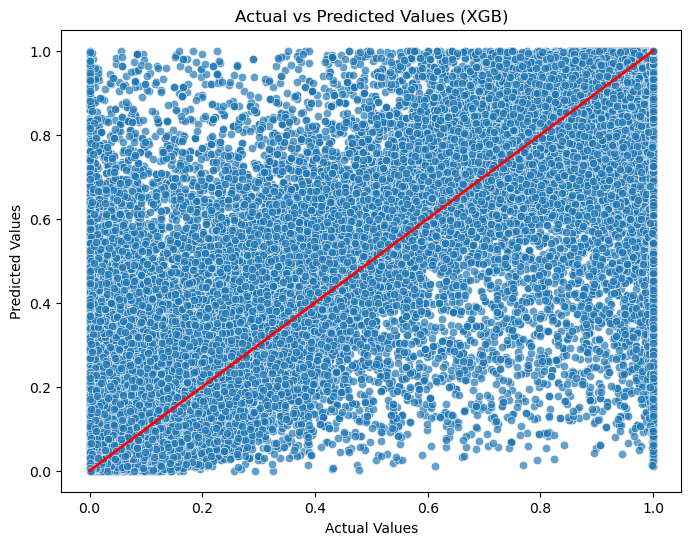

In [ ]:
plt.figure(figsize=(8,6))
sns.scatterplot(x=y_test.flatten(), y=y_pred.flatten(), alpha=0.7)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted Values (XGB)")
# Add a perfect prediction line
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color='red', lw=2)
plt.show()


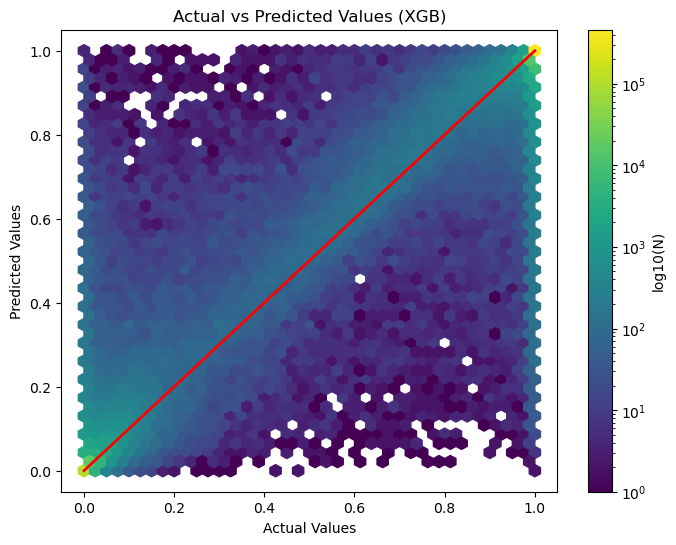

In [ ]:
plt.figure(figsize=(8,6))
plt.hexbin(
    y_test.flatten(), 
    y_pred.flatten(), 
    gridsize=40,  # smaller → finer grid
    cmap='viridis', 
    bins='log'  # logarithmic scaling helps emphasize dense areas
)
plt.colorbar(label='log10(N)')
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color='red', lw=2
)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted Values (XGB)")
plt.show()


BART

In [ ]:
#BART

# bart_condensates = BART(random_state=0, burnin=100, ndraw=15)
# bart_condensates.fit(X_train, y_train)

In [ ]:
# yhat_test = bart_condensates.predict(X_test.astype(np.float32))

# yhat_test = np.clip(yhat_test, 0, 1)
# np.mean((y_test- yhat_test)**2)

In [ ]:
# var_inclusion = pd.Series(bart_condensates.variable_inclusion_.mean(0),
#  index=D.columns)
# var_inclusion

In [ ]:
overall_end_time = time.time()

totalElapsedTime=overall_end_time - overall_start_time
print(f"The Total Elapsed Time is: {totalElapsedTime/60:.4f} minutes")

The Total Elapsed Time is: 8.7238 minutes
